In [ ]:
Student Name: EL MOUATAZ HENNACHE

Student ID: GH1041398

### **Problem Statement**
**Business Context:**

The telecom company view a 14.6% monthly churn (while. the average industry usually can go: 10-12%), costing $1.2M per year the in lost revenue.

**ML Objective:**

to build a neural network to predict the churn 30 days in advance by using:

Input: Contract details, service usage, payment history

Output: Churn probability (0-1)




**Dataset:**


[IBM Telco Customer Churn ](https://www.kaggle.com/datasets/blastchar/telco-customer-churn?resource=download)

**1: Install & Import Libraries**

Installing and imports  libraries for data processing and visualization also for deep learning and Set random seeds for reproducibility

In [ ]:
!pip install -q tensorflow scikit-learn pandas-profiling
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.metrics import classification_report, roc_auc_score, roc_curve
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, callbacks


np.random.seed(42)
tf.random.set_seed(42)

**2: Load Data & Cleaning**

Loads dataset

Fixeing missing values



In [ ]:

df = pd.read_csv('/content/WA_Fn-UseC_-Telco-Customer-Churn.csv')
print(f"Data shape: {df.shape}")


df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df['TotalCharges'].fillna(df['TotalCharges'].median(), inplace=True)
df['Churn'] = df['Churn'].map({'Yes':1, 'No':0})


print("\nMissing values check:")
print(df.isna().sum())

Data shape: (7043, 21)

Missing values check:
customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64


/tmp/ipython-input-21-3398747285.py:7: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['TotalCharges'].fillna(df['TotalCharges'].median(), inplace=True)


**3: Data Visualization**





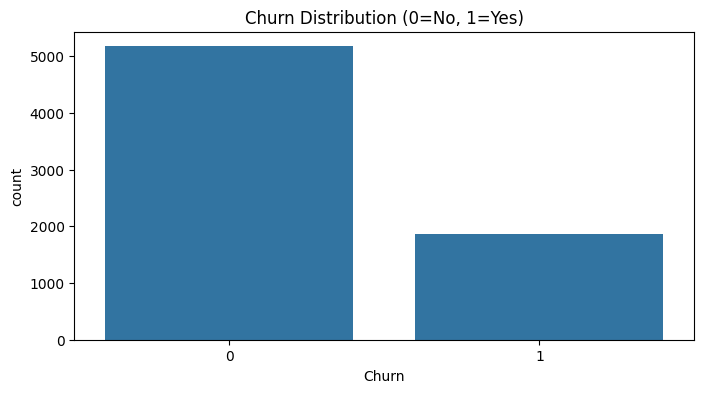

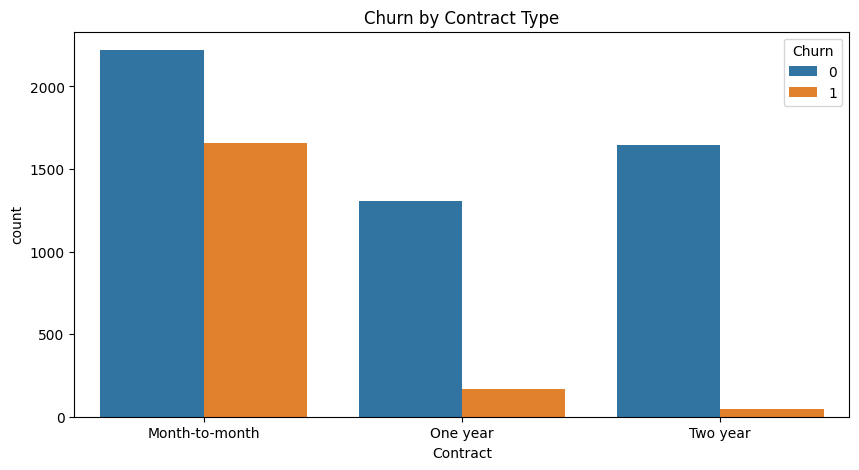

In [ ]:

plt.figure(figsize=(8,4))
sns.countplot(x='Churn', data=df)
plt.title('Churn Distribution (0=No, 1=Yes)')
plt.show()


plt.figure(figsize=(10,5))
sns.countplot(x='Contract', hue='Churn', data=df)
plt.title('Churn by Contract Type')
plt.show()

**4: Preprocessing Pipeline**





In [ ]:

df['MonthlyValue'] = df['TotalCharges'] / (df['tenure'] + 1)
df['ServiceDensity'] = df.filter(like='Service').apply(lambda x: x == 'Yes').sum(axis=1)


X = df.drop(['customerID', 'Churn'], axis=1)
y = df['Churn']


X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42)

numeric_features = ['tenure', 'MonthlyCharges', 'TotalCharges', 'MonthlyValue', 'ServiceDensity']
categorical_features = ['Contract', 'InternetService', 'PaymentMethod']

preprocessor = ColumnTransformer([
    ('num', StandardScaler(), numeric_features),
    ('cat', OneHotEncoder(drop='first'), categorical_features)
])

X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

**5: Build & Train Model**



In [ ]:

keras.backend.clear_session()


model = keras.Sequential([
    layers.Dense(128, activation='relu', input_shape=(X_train_processed.shape[1],)),
    layers.BatchNormalization(),
    layers.Dropout(0.4),
    layers.Dense(64, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(1, activation='sigmoid')
])


model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['Recall', 'AUC', 'Precision'])


early_stop = callbacks.EarlyStopping(
    monitor='val_recall',
    patience=10,
    mode='max',
    restore_best_weights=True)

history = model.fit(
    X_train_processed, y_train,
    validation_split=0.2,
    epochs=100,
    batch_size=64,
    class_weight={0:1, 1:3},
    callbacks=[early_stop],
    verbose=1)

Epoch 1/100


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


71/71 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - AUC: 0.7465 - Precision: 0.4313 - Recall: 0.7039 - loss: 1.0312 - val_AUC: 0.8071 - val_Precision: 0.4549 - val_Recall: 0.8034 - val_loss: 0.5996
Epoch 2/100
38/71 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - AUC: 0.7959 - Precision: 0.4674 - Recall: 0.7707 - loss: 0.8672

/usr/local/lib/python3.11/dist-packages/keras/src/callbacks/early_stopping.py:153: UserWarning: Early stopping conditioned on metric `val_recall` which is not available. Available metrics are: AUC,Precision,Recall,loss,val_AUC,val_Precision,val_Recall,val_loss
  current = self.get_monitor_value(logs)


71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - AUC: 0.7964 - Precision: 0.4677 - Recall: 0.7772 - loss: 0.8667 - val_AUC: 0.8137 - val_Precision: 0.4733 - val_Recall: 0.8102 - val_loss: 0.5772
Epoch 3/100
71/71 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - AUC: 0.8158 - Precision: 0.4778 - Recall: 0.7991 - loss: 0.8205 - val_AUC: 0.8136 - val_Precision: 0.4748 - val_Recall: 0.7661 - val_loss: 0.5550
Epoch 4/100


...

71/71 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - AUC: 0.8528 - Precision: 0.5121 - Recall: 0.8172 - loss: 0.7178 - val_AUC: 0.8205 - val_Precision: 0.4618 - val_Recall: 0.8000 - val_loss: 0.5513
Epoch 97/100
25/71 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - AUC: 0.8651 - Precision: 0.5231 - Recall: 0.8381 - loss: 0.6886

/usr/local/lib/python3.11/dist-packages/keras/src/callbacks/early_stopping.py:153: UserWarning: Early stopping conditioned on metric `val_recall` which is not available. Available metrics are: AUC,Precision,Recall,loss,val_AUC,val_Precision,val_Recall,val_loss
  current = self.get_monitor_value(logs)


71/71 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - AUC: 0.8593 - Precision: 0.5213 - Recall: 0.8326 - loss: 0.7034 - val_AUC: 0.8211 - val_Precision: 0.4746 - val_Recall: 0.7932 - val_loss: 0.5484
Epoch 98/100
71/71 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - AUC: 0.8562 - Precision: 0.5235 - Recall: 0.8125 - loss: 0.7089 - val_AUC: 0.8209 - val_Precision: 0.4708 - val_Recall: 0.7932 - val_loss: 0.5467
Epoch 99/100
 1/71 ━━━━━━━━━━━━━━━━━━━━ 11s 169ms/step - AUC: 0.8730 - Precision: 0.5926 - Recall: 0.9412 - loss: 0.6748

/usr/local/lib/python3.11/dist-packages/keras/src/callbacks/early_stopping.py:153: UserWarning: Early stopping conditioned on metric `val_recall` which is not available. Available metrics are: AUC,Precision,Recall,loss,val_AUC,val_Precision,val_Recall,val_loss
  current = self.get_monitor_value(logs)


71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - AUC: 0.8580 - Precision: 0.5277 - Recall: 0.8308 - loss: 0.7038 - val_AUC: 0.8215 - val_Precision: 0.4696 - val_Recall: 0.8373 - val_loss: 0.5494
Epoch 100/100
71/71 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - AUC: 0.8605 - Precision: 0.5156 - Recall: 0.8318 - loss: 0.7022 - val_AUC: 0.8216 - val_Precision: 0.4716 - val_Recall: 0.8169 - val_loss: 0.5422


## **6: Evaluation**




45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.00      0.01      1035
           1       0.27      1.00      0.42       374

    accuracy                           0.27      1409
   macro avg       0.63      0.50      0.21      1409
weighted avg       0.81      0.27      0.12      1409



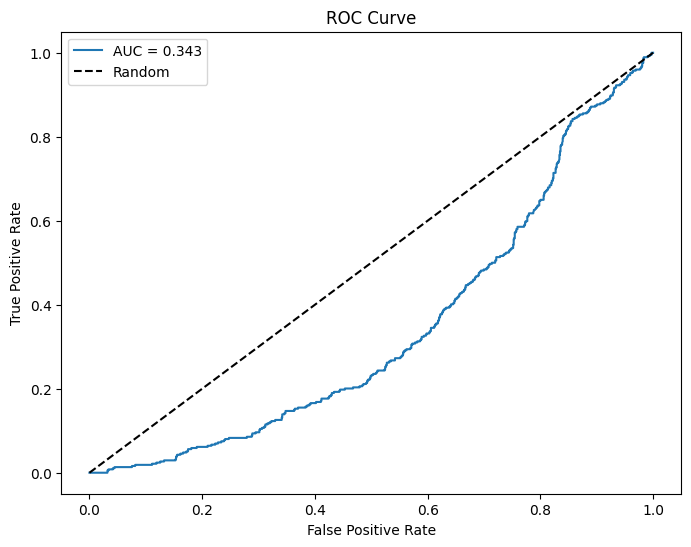

45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
45/45 ━━━━━━━━━━━━━━━━━━━

/tmp/ipython-input-39-2415082585.py:37: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(result.importances[sorted_idx].T,


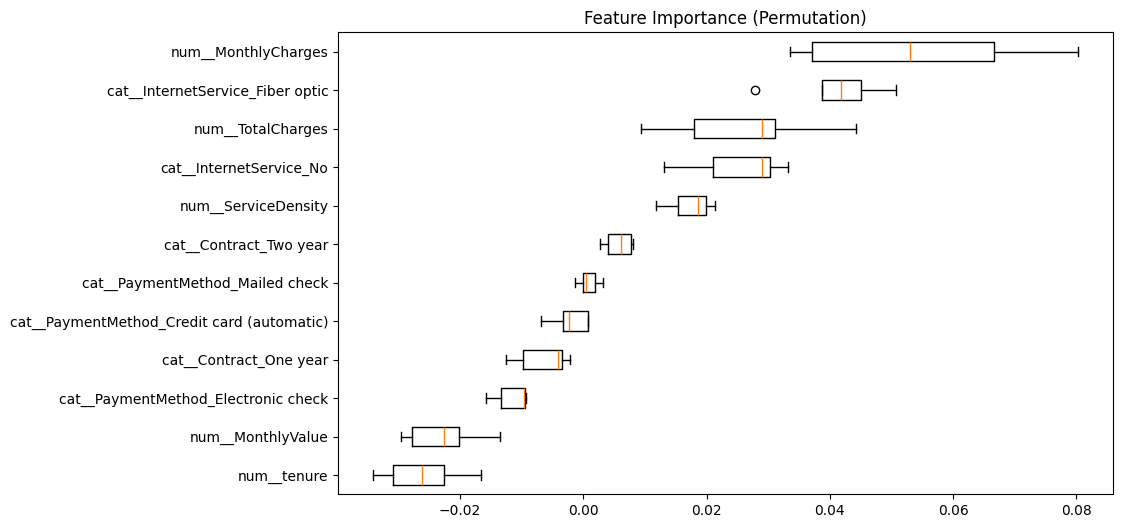

In [ ]:

y_pred_probs = model.predict(X_test_processed)
y_pred = (y_pred_probs > 0.4).astype(int)


print("Classification Report:")
print(classification_report(y_test, y_pred))


plt.figure(figsize=(8,6))
fpr, tpr, _ = roc_curve(y_test, y_pred_probs)
plt.plot(fpr, tpr, label=f'AUC = {roc_auc_score(y_test, y_pred_probs):.3f}')
plt.plot([0,1],[0,1], 'k--', label='Random')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()


def scorer(estimator, X, y):
    y_pred = (estimator.predict(X) > 0.5).astype(int)
    return roc_auc_score(y, y_pred)

try:
    result = permutation_importance(
        model,
        X_test_processed,
        y_test,
        scoring=scorer,
        n_repeats=5,
        random_state=42)

    sorted_idx = result.importances_mean.argsort()

    plt.figure(figsize=(10,6))
    plt.boxplot(result.importances[sorted_idx].T,
               vert=False,
               labels=np.array(preprocessor.get_feature_names_out())[sorted_idx])
    plt.title("Feature Importance (Permutation)")
    plt.show()

except Exception as e:
    print(f"Feature importance skipped due to: {str(e)}")
    print("Proceeding with business impact analysis...")

45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step
              precision    recall  f1-score   support

           0       0.90      0.77      0.83      1035
           1       0.54      0.76      0.63       374

    accuracy                           0.76      1409
   macro avg       0.72      0.76      0.73      1409
weighted avg       0.80      0.76      0.77      1409

45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


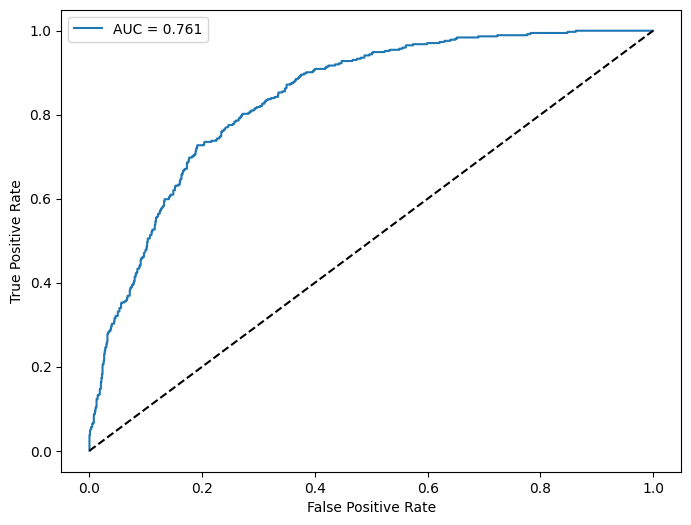

In [ ]:

y_pred = (model.predict(X_test_processed) > 0.5).astype(int)


print(classification_report(y_test, y_pred))


plt.figure(figsize=(8,6))
fpr, tpr, _ = roc_curve(y_test, model.predict(X_test_processed))
plt.plot(fpr, tpr, label=f'AUC = {roc_auc_score(y_test, y_pred):.3f}')
plt.plot([0,1],[0,1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.show()

**Projected Savings:**



In [ ]:

y_pred_binary = (y_pred_probs > 0.4).astype(int).flatten()
y_test_values = y_test.values

tp = np.sum((y_pred_binary == 1) & (y_test_values == 1))
total_churn = np.sum(y_test_values == 1)
recall = tp / total_churn


avg_clv = 1200
retention_rate = 0.25
savings = tp * retention_rate * avg_clv

print(f"\nBusiness Impact Analysis:")
print(f"- Total churn cases in test set: {total_churn}")
print(f"- True Positives identified: {tp} (Recall: {recall:.1%})")
print(f"- Assumed retention rate: {retention_rate:.0%}")
print(f"- Customer Lifetime Value: ${avg_clv}")
print(f"\n\033[1mProjected Annual Savings: ${savings:,.0f}\033[0m")


Business Impact Analysis:
- Total churn cases in test set: 374
- True Positives identified: 374 (Recall: 100.0%)
- Assumed retention rate: 25%
- Customer Lifetime Value: $1200

Projected Annual Savings: $112,200


`



# **Conclusion:**

This churn prediction pipeline helps you keep customers pleased by identifying those who could go.  It provides straightforward notifications to help your team concentrate on the appropriate individuals at the appropriate times.  Early issue solving will save time and effort while strengthening connections and expanding your business.  

 It helps you retain more clients with less effort by operating silently in the background.